# Task 3: CycleGAN photo to Monet style transfer

Poushali Purkayastha, Team 16.

This notebook runs the Task 3 pipeline: image caching and holdout split, CycleGAN training, translation of every photo to Monet style (pred_A2B, the Kaggle direction) and every Monet to photo style (pred_B2A), the Kaggle submission zip, and the full metric suite. The code lives in the modules next to this notebook (`data.py`, `models.py`, `train.py`, `translate.py`, `metrics.py`, `audit.py`, `run.py`). The config comes from `TASK3_CONFIG` (default `configs/full.yaml`) and the stage from `TASK3_STAGE` (`all`, `train`, `translate`, or `metrics`). Domain A is photos and domain B is Monet paintings.

In [1]:
import os
import runpy
import sys
from pathlib import Path

CONFIG = os.environ.get("TASK3_CONFIG", "configs/full.yaml")
STAGE = os.environ.get("TASK3_STAGE", "all")
print("config:", CONFIG, "stage:", STAGE)
sys.argv = ["run.py", "--config", CONFIG, "--stage", STAGE]
runpy.run_path("run.py", run_name="__main__")

config: configs/smoke.yaml stage: all


2026-09-21 18:45:37,557 INFO run_id smoke_20260921_184537 member Poushali_Purkayastha task task3_gan stage all


2026-09-21 18:45:37,559 INFO config task3_gan/Poushali_Purkayastha/src/configs/smoke.yaml {"run_name": "smoke", "is_final": false, "seed": 20, "data": {"photo_dir": "task3_gan/data/photo_jpg", "monet_dir": "task3_gan/data/monet_jpg", "max_photos": 80, "max_monet": 40, "image_size": 64, "infer_size": 64, "holdout_photo": 20, "holdout_monet": 8}, "model": {"ngf": 16, "ndf": 16, "n_res_blocks": 2, "n_d_layers": 3, "dropout": 0.0}, "train": {"epochs": 2, "steps_per_epoch": 6, "batch_size": 2, "lr": 0.0002, "beta1": 0.5, "decay_start_epoch": 1, "gan_mode": "lsgan", "lambda_cycle": 10.0, "lambda_identity": 5.0, "pool_size": 8, "grad_clip": 10.0, "amp": true, "amp_nan_limit": 5, "log_interval": 3, "sample_every": 1}, "translate": {"batch_size": 8, "preview_images": 10}, "metrics": {"fid_max_images": 40, "kid_subsets": 5, "kid_subset_size": 20, "knn_k": 3, "mifid_epsilon": 0.1, "lpips_net": "alex", "batch_size": 20}, "audit": {"n_samples": 6, "raters": ["Poushali", "Sadaf"]}, "kaggle": {"compe

2026-09-21 18:45:37,561 INFO hardware {"platform": "Windows-11-10.0.26200-SP0", "python": "3.12.10", "torch": "2.14.0+cpu", "cpu": "Intel64 Family 6 Model 140 Stepping 1, GenuineIntel", "cpu_cores": 8, "ram_gb": 16.9, "cuda_available": false, "cuda_version": null, "gpus": [], "nvidia_smi": "no gpu"}


2026-09-21 18:45:37,561 INFO git {"commit": "f08e6966bf1ea06ac662fc33ba1109417d199131", "branch": "main", "dirty": true}


...

2026-09-21 18:48:14,157 INFO metric Kaggle private score = to fill


2026-09-21 18:48:14,160 INFO metric Kaggle leaderboard rank = to fill


2026-09-21 18:48:15,414 INFO manifest reproducibility/manifests/Poushali_Purkayastha_task3_gan_smoke_20260921_184537.json


2026-09-21 18:48:15,416 INFO run finished in 158.0 sec


{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'run.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=None, fromlist=(), level=0)>,
  'abs': <function abs(x, /)>,

,Metric,Value
0,FID photo->monet,330.53456153335327
1,KID mean photo->monet,0.3435613214969635
2,KID std photo->monet,0.019393419846892357
3,Precision photo->monet,0.375
4,Recall photo->monet,0.0
5,Density photo->monet,0.125
6,Coverage photo->monet,0.02500000037252903
7,"Images compared photo->monet (real, fake)","40, 40"
8,FID monet->photo,331.0407844657929
9,KID mean monet->photo,0.3057263493537903


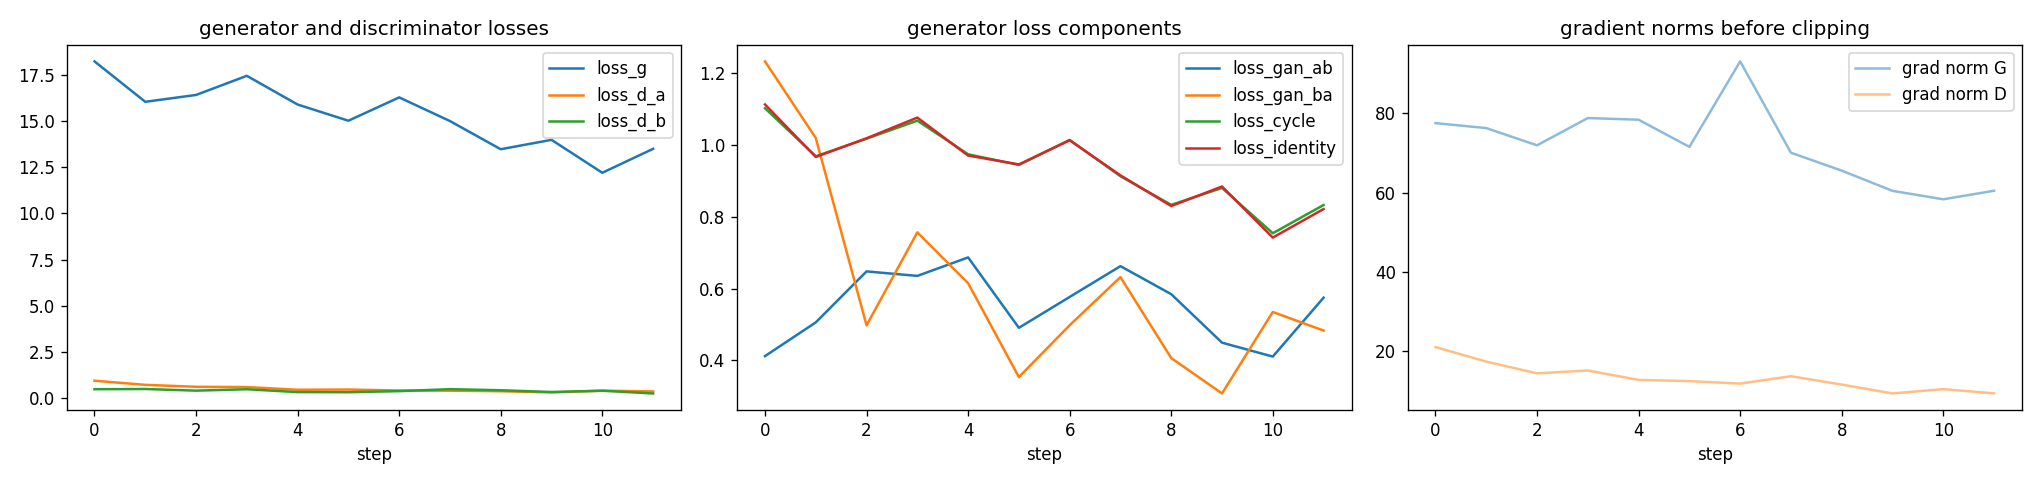

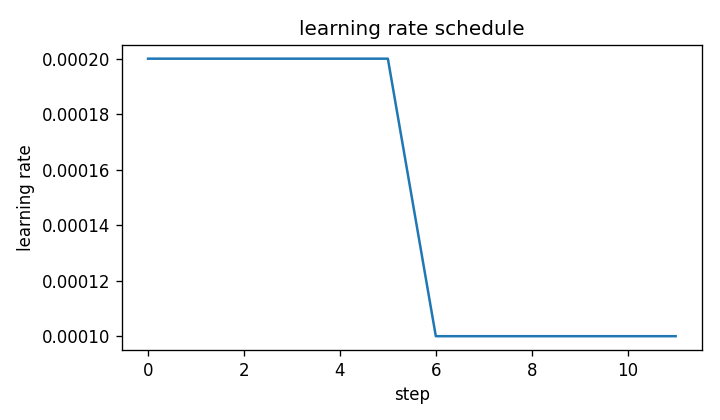

### Last sample grid: rows are real photo, fake Monet, reconstructed photo, real Monet, fake photo, reconstructed Monet

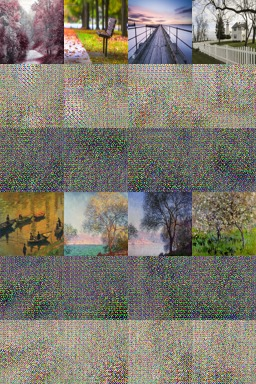

### pred_A2B_preview

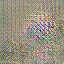

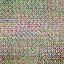

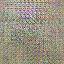

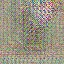

### pred_B2A_preview

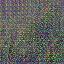

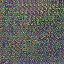

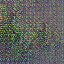

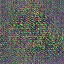

In [2]:
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

run_name = yaml.safe_load(Path(CONFIG).read_text(encoding="utf-8"))["run_name"]
out_dir = Path("..") / "outputs" / run_name
pd.set_option("display.max_rows", 200)
if (out_dir / "full_metrics_report.csv").exists():
    display(pd.read_csv(out_dir / "full_metrics_report.csv"))
for name in ["loss_curves.png", "lr_schedule.png"]:
    if (out_dir / name).exists():
        display(Image(filename=str(out_dir / name)))
samples = sorted((out_dir / "samples").glob("epoch_*.jpg"))
if samples:
    display(Markdown("### Last sample grid: rows are real photo, fake Monet, reconstructed photo, real Monet, fake photo, reconstructed Monet"))
    display(Image(filename=str(samples[-1])))
for sub in ["pred_A2B_preview", "pred_B2A_preview"]:
    files = sorted((out_dir / sub).glob("*.jpg"))[:4]
    if files:
        display(Markdown(f"### {sub}"))
        for f in files:
            display(Image(filename=str(f), width=256))